**Denoising Encoders**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.3877 - val_loss: 0.3311
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3229 - val_loss: 0.3202
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3143 - val_loss: 0.3144
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.3093 - val_loss: 0.3100
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3059 - val_loss: 0.3078
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3036 - val_loss: 0.3060
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.3019 - val_loss: 0.3041
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3005 - val_loss: 0.3027
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2990 - val_loss: 0.3019
Epoch 10/10
235/235 ━━━━━━━━━

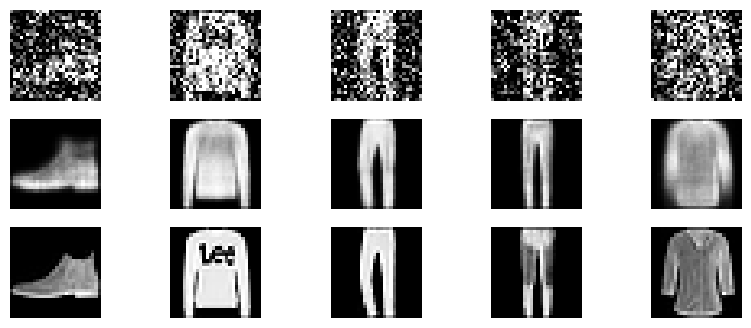

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model

# Load dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Encoder
input_img = Input(shape=(28,28,1))
x = Flatten()(input_img)
x = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(128, activation='relu')(encoded)
x = Dense(28*28, activation='sigmoid')(x)
decoded = Reshape((28,28,1))(x)

# Model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

# Predict
decoded_imgs = autoencoder.predict(x_test_noisy)

# Visualization
n = 5
plt.figure(figsize=(10,4))
for i in range(n):

    # Noisy image
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    # Original
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()